# 🎮 DifficultyMiner — Exploratory Data Analysis
### Game Difficulty Predictor from Player Reviews

**Objective:** Explore and understand the Steam player reviews dataset before any modelling.

---

### 📑 Notebook Outline
1. Setup & Imports  
2. Data Loading & First Look  
3. Data Quality Check (missing values, duplicates, types)  
4. Univariate Analysis  
5. Bivariate / Multivariate Analysis  
6. Text Overview  
7. Correlation Analysis  
8. Key Takeaways & Next Steps

## 1️⃣ Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
from collections import Counter
from matplotlib.lines import Line2D

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams.update({
    "figure.figsize": (14, 6),
    "axes.titlesize": 15,
    "axes.labelsize": 12,
    "figure.dpi": 120,
    "savefig.bbox": "tight"
})

COLORS = {
    "primary":   "#6366f1",
    "secondary": "#f59e0b",
    "positive":  "#10b981",
    "negative":  "#ef4444",
    "neutral":   "#6b7280",
    "palette":   ["#6366f1","#f59e0b","#10b981","#ef4444","#3b82f6",
                  "#ec4899","#8b5cf6","#14b8a6","#f97316","#64748b","#a855f7"]
}
print("✅ Libraries loaded successfully")

✅ Libraries loaded successfully


## 2️⃣ Data Loading & First Look

In [2]:
df = pd.read_csv("reviews.csv")

print(f"{'='*60}")
print(f"  📦 Dataset Shape : {df.shape[0]} rows × {df.shape[1]} columns")
print(f"{'='*60}")
df.head()

  📦 Dataset Shape : 904 rows × 10 columns


,game_id,game_name,steamid,review_len_chars,review_len_words,votes_helpful,votes_funny,recommended,playtime,review_text
0,570,Dota 2,76561198072667781,106,19,0,0,True,110861,fun ivolved game. the people you play with can...
1,570,Dota 2,76561197994095598,47,10,0,0,False,64719,Anyone who recommends DOTA 2 to you is a troll.
2,570,Dota 2,76561198019967090,6,1,1,1,True,236352,Don't.
3,570,Dota 2,76561197975557115,3,1,0,0,True,283522,Yep
4,730,Counter-Strike 2,76561199098421681,160,28,517,163,True,4752,CS2 Got me into an gambling addiction and it c...


In [3]:
df.tail()

,game_id,game_name,steamid,review_len_chars,review_len_words,votes_helpful,votes_funny,recommended,playtime,review_text
899,311210,Call of Duty®: Black Ops III,76561199122681490,65,14,0,0,True,2613,"love this game, its so old so zombies with mod..."
900,311210,Call of Duty®: Black Ops III,76561199529963277,69,13,0,0,True,796,games great i love grinding the easter eggs an...
901,311210,Call of Duty®: Black Ops III,76561199108143694,286,52,1,0,True,1442,Really good CoD Zombies!\r \r Black Ops III is...
902,311210,Call of Duty®: Black Ops III,76561199226855895,126,24,0,0,True,187,Black Ops 3 is the last perfected game of Blac...
903,311210,Call of Duty®: Black Ops III,76561199511006613,155,29,0,0,False,2894,this game should be rated mixed the content af...


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 904 entries, 0 to 903
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   game_id           904 non-null    int64 
 1   game_name         904 non-null    object
 2   steamid           904 non-null    int64 
 3   review_len_chars  904 non-null    int64 
 4   review_len_words  904 non-null    int64 
 5   votes_helpful     904 non-null    int64 
 6   votes_funny       904 non-null    int64 
 7   recommended       904 non-null    bool  
 8   playtime          904 non-null    int64 
 9   review_text       904 non-null    object
dtypes: bool(1), int64(7), object(2)
memory usage: 64.6+ KB


In [5]:
print("📊 Descriptive Statistics — Numerical Columns\n")
df.describe().round(2)

📊 Descriptive Statistics — Numerical Columns



,game_id,steamid,review_len_chars,review_len_words,votes_helpful,votes_funny,playtime
count,904.00,9.040000e+02,904.00,904.00,904.00,904.00,904.00
mean,1322446.11,7.656120e+16,412.18,73.78,4.22,0.85,17710.60
std,1141346.15,6.118289e+08,773.91,134.14,36.50,8.77,50117.15
min,440.00,7.656120e+16,3.00,1.00,0.00,0.00,5.00
25%,311210.00,7.656120e+16,98.00,18.00,0.00,0.00,1066.00
50%,1245620.00,7.656120e+16,177.00,33.00,0.00,0.00,3533.00
75%,2358720.00,7.656120e+16,385.75,70.00,1.00,0.00,12263.75
max,3240220.00,7.656120e+16,7994.00,1446.00,678.00,168.00,899914.00


In [6]:
print("📊 Descriptive Statistics — Categorical Columns\n")
df.describe(include="object")

📊 Descriptive Statistics — Categorical Columns



,game_name,review_text
count,904,904
unique,10,903
top,Counter-Strike 2,"It's a really good game, I've been playing thi..."
freq,100,2


In [7]:
print("📊 Column Data Types\n")
print(df.dtypes)
print(f"\n📐 Memory Usage: {df.memory_usage(deep=True).sum() / 1024:.1f} KB")

📊 Column Data Types

game_id              int64
game_name           object
steamid              int64
review_len_chars     int64
review_len_words     int64
votes_helpful        int64
votes_funny          int64
recommended           bool
playtime             int64
review_text         object
dtype: object

📐 Memory Usage: 645.1 KB


## 3️⃣ Data Quality Check
A quick health check: missing values, duplicates, and basic type verification.  
**No feature engineering or classification at this stage** — just understanding what we have.

🔍 Missing Values per Column:

                  missing_count  missing_pct (%)
game_id                       0              0.0
game_name                     0              0.0
steamid                       0              0.0
review_len_chars              0              0.0
review_len_words              0              0.0
votes_helpful                 0              0.0
votes_funny                   0              0.0
recommended                   0              0.0
playtime                      0              0.0
review_text                   0              0.0


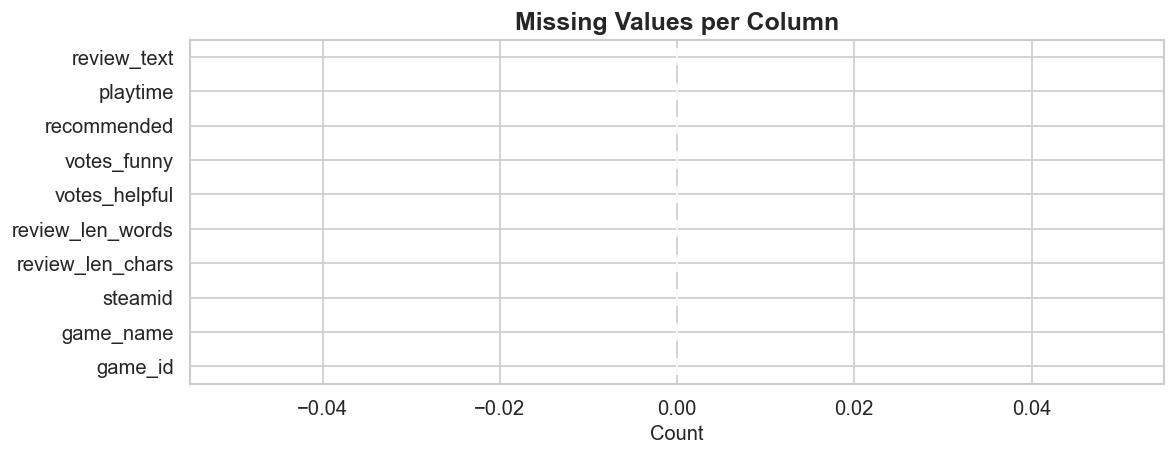

In [8]:
# --- Missing values ---
print("🔍 Missing Values per Column:\n")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({"missing_count": missing, "missing_pct (%)": missing_pct})
print(missing_df.to_string())

# Visualize
fig, ax = plt.subplots(figsize=(10, 4))
missing.plot.barh(color=[COLORS["negative"] if v > 0 else COLORS["positive"] for v in missing], ax=ax)
ax.set_title("Missing Values per Column", fontweight="bold")
ax.set_xlabel("Count")
plt.tight_layout()
plt.show()

In [9]:
# --- Duplicates ---
dup_count = df.duplicated().sum()
print(f"🔁 Duplicate rows: {dup_count}")
if dup_count > 0:
    print("   → Previewing duplicates:")
    display(df[df.duplicated(keep=False)].head(10))
else:
    print("   ✅ No duplicates found")

🔁 Duplicate rows: 0
   ✅ No duplicates found


In [10]:
# --- Unique values per column ---
print("🔢 Unique Values per Column:\n")
for col in df.columns:
    print(f"   {col:25s} → {df[col].nunique():>6} unique values")

🔢 Unique Values per Column:

   game_id                   →     10 unique values
   game_name                 →     10 unique values
   steamid                   →    901 unique values
   review_len_chars          →    485 unique values
   review_len_words          →    222 unique values
   votes_helpful             →     38 unique values
   votes_funny               →     19 unique values
   recommended               →      2 unique values
   playtime                  →    874 unique values
   review_text               →    903 unique values


In [11]:
# --- Convert playtime to hours for readability ---
df["playtime_hours"] = (df["playtime"] / 60).round(1)
df["recommended"] = df["recommended"].astype(bool)
print("✅ Added playtime_hours column, cast recommended to bool")
print(f"   Shape: {df.shape}")

✅ Added playtime_hours column, cast recommended to bool
   Shape: (904, 11)


## 4️⃣ Univariate Analysis

### 4.1 — Reviews per Game

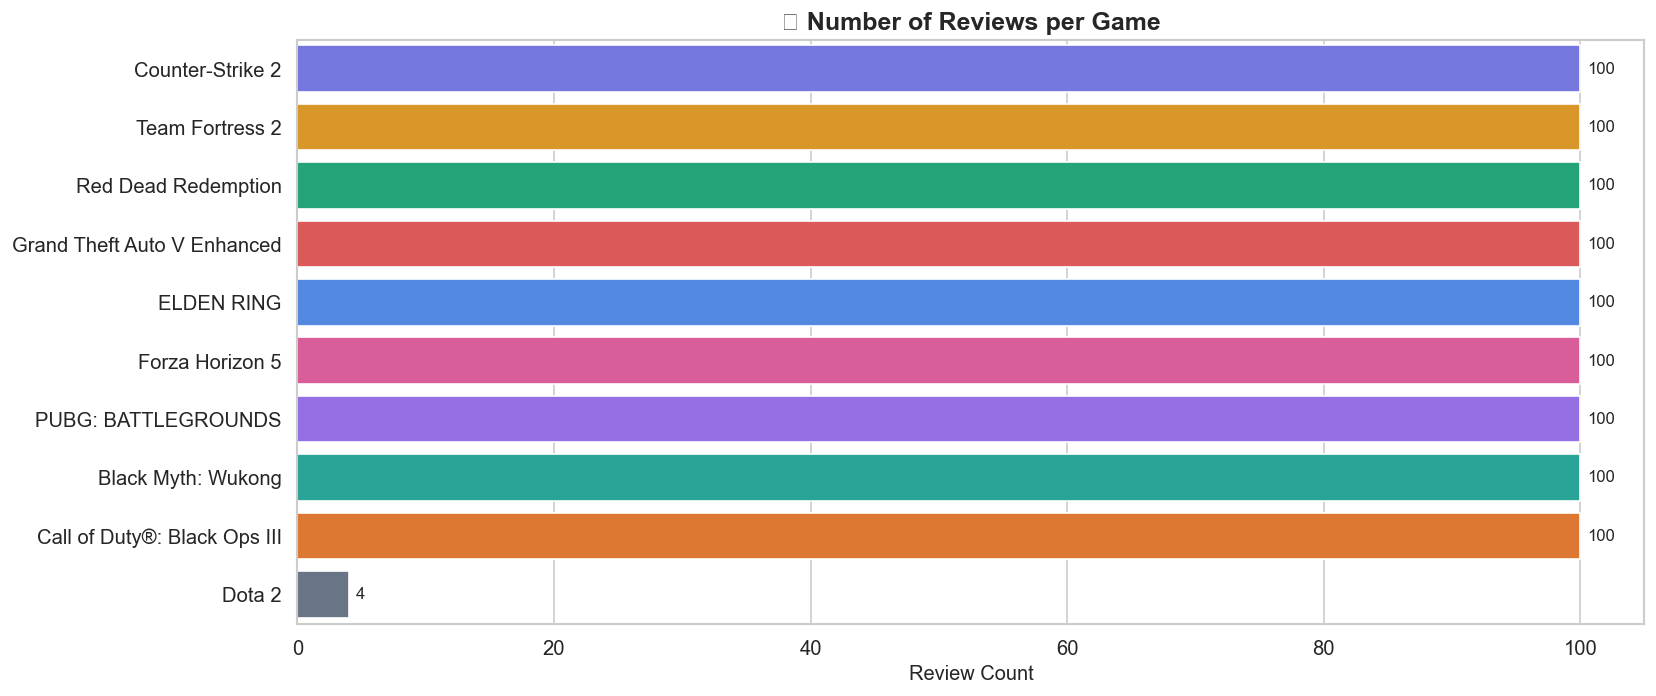

In [12]:
fig, ax = plt.subplots(figsize=(14, 6))
order = df["game_name"].value_counts().index
sns.countplot(data=df, y="game_name", order=order, palette=COLORS["palette"], ax=ax)
ax.set_title("📊 Number of Reviews per Game", fontweight="bold")
ax.set_xlabel("Review Count")
ax.set_ylabel("")
for container in ax.containers:
    ax.bar_label(container, fmt="%d", padding=4, fontsize=10)
plt.tight_layout()
plt.show()

### 4.2 — Recommendation Distribution

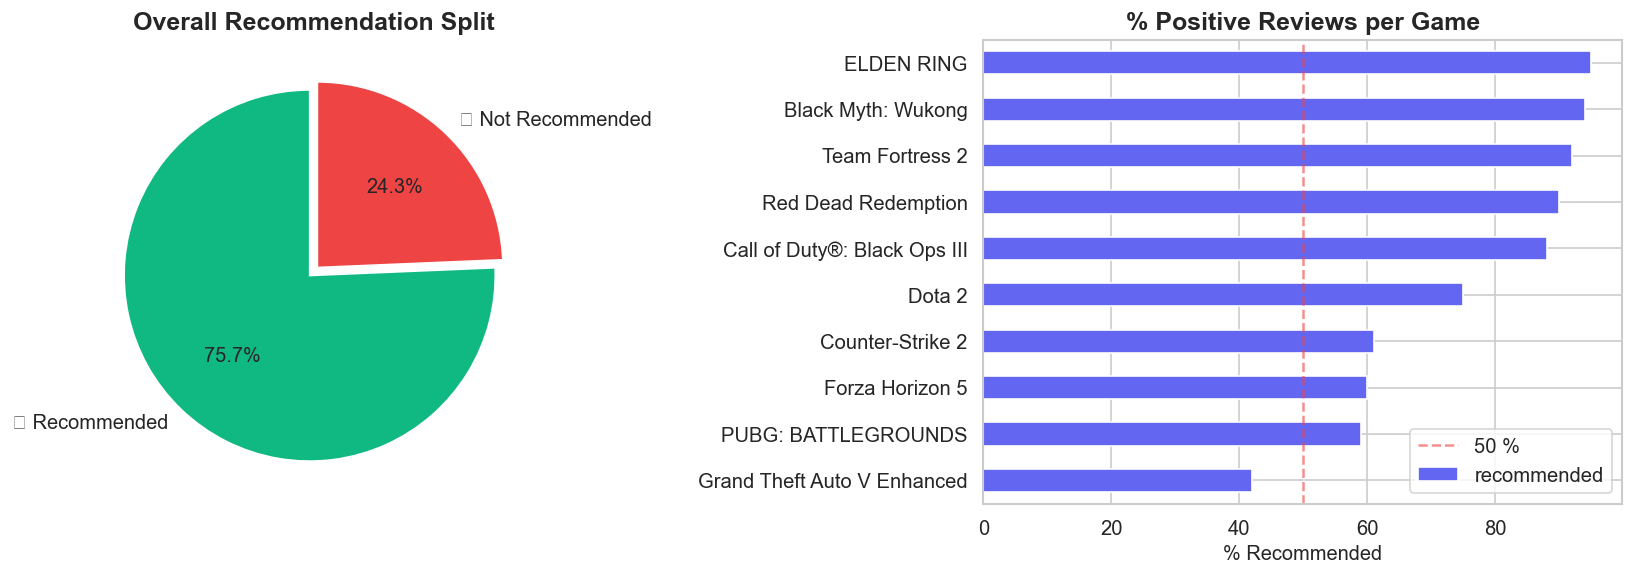

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall pie
rec_counts = df["recommended"].value_counts()
labels = ["👍 Recommended", "👎 Not Recommended"]
axes[0].pie(rec_counts, labels=labels, autopct="%1.1f%%", startangle=90,
            colors=[COLORS["positive"], COLORS["negative"]],
            explode=(0.03, 0.03), textprops={"fontsize": 12})
axes[0].set_title("Overall Recommendation Split", fontweight="bold")

# Per game
rec_pct = (df.groupby("game_name")["recommended"].mean().sort_values() * 100)
rec_pct.plot.barh(ax=axes[1], color=COLORS["primary"])
axes[1].set_title("% Positive Reviews per Game", fontweight="bold")
axes[1].set_xlabel("% Recommended")
axes[1].set_ylabel("")
axes[1].axvline(50, ls="--", color=COLORS["negative"], alpha=0.6, label="50 %")
axes[1].legend()
plt.tight_layout()
plt.show()

### 4.3 — Review Length Distribution

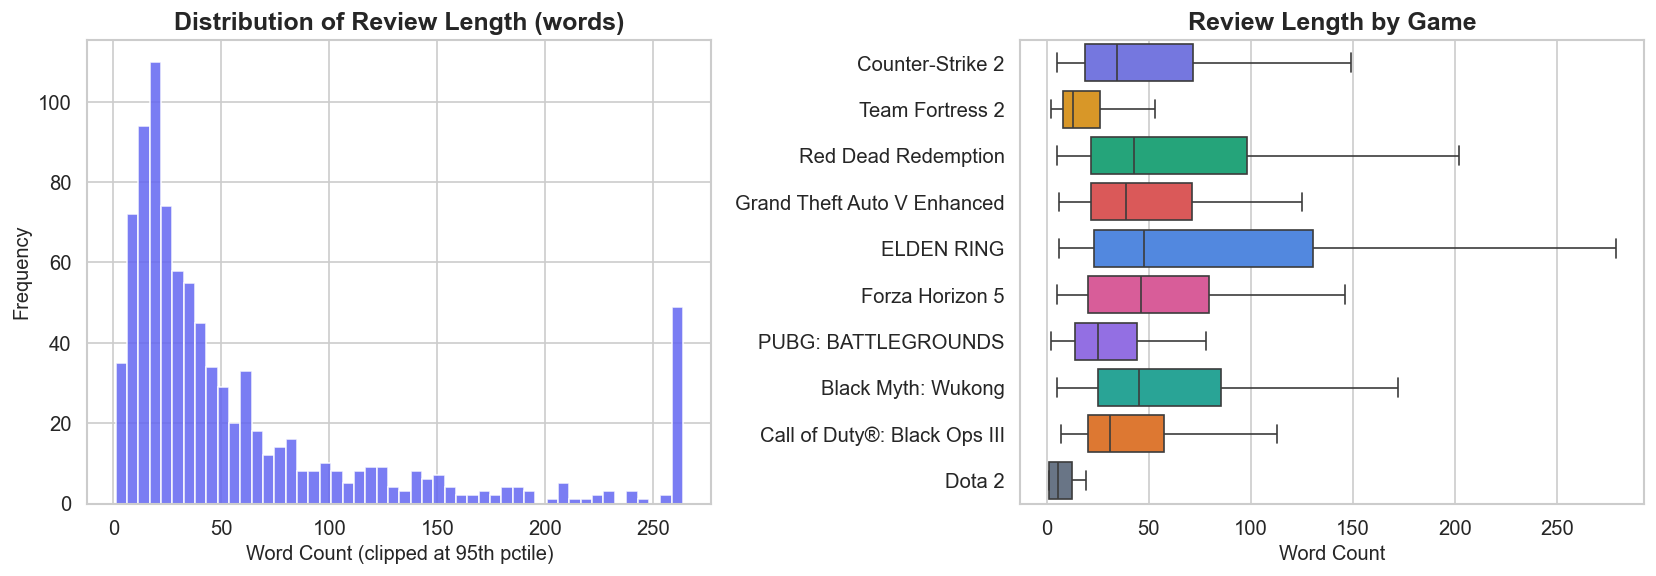

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df["review_len_words"].clip(upper=df["review_len_words"].quantile(0.95)).hist(
    bins=50, ax=axes[0], color=COLORS["primary"], edgecolor="white", alpha=0.85)
axes[0].set_title("Distribution of Review Length (words)", fontweight="bold")
axes[0].set_xlabel("Word Count (clipped at 95th pctile)")
axes[0].set_ylabel("Frequency")

sns.boxplot(data=df, x="review_len_words", y="game_name",
            order=order, palette=COLORS["palette"], ax=axes[1], showfliers=False)
axes[1].set_title("Review Length by Game", fontweight="bold")
axes[1].set_xlabel("Word Count")
axes[1].set_ylabel("")
plt.tight_layout()
plt.show()

### 4.4 — Playtime Distribution

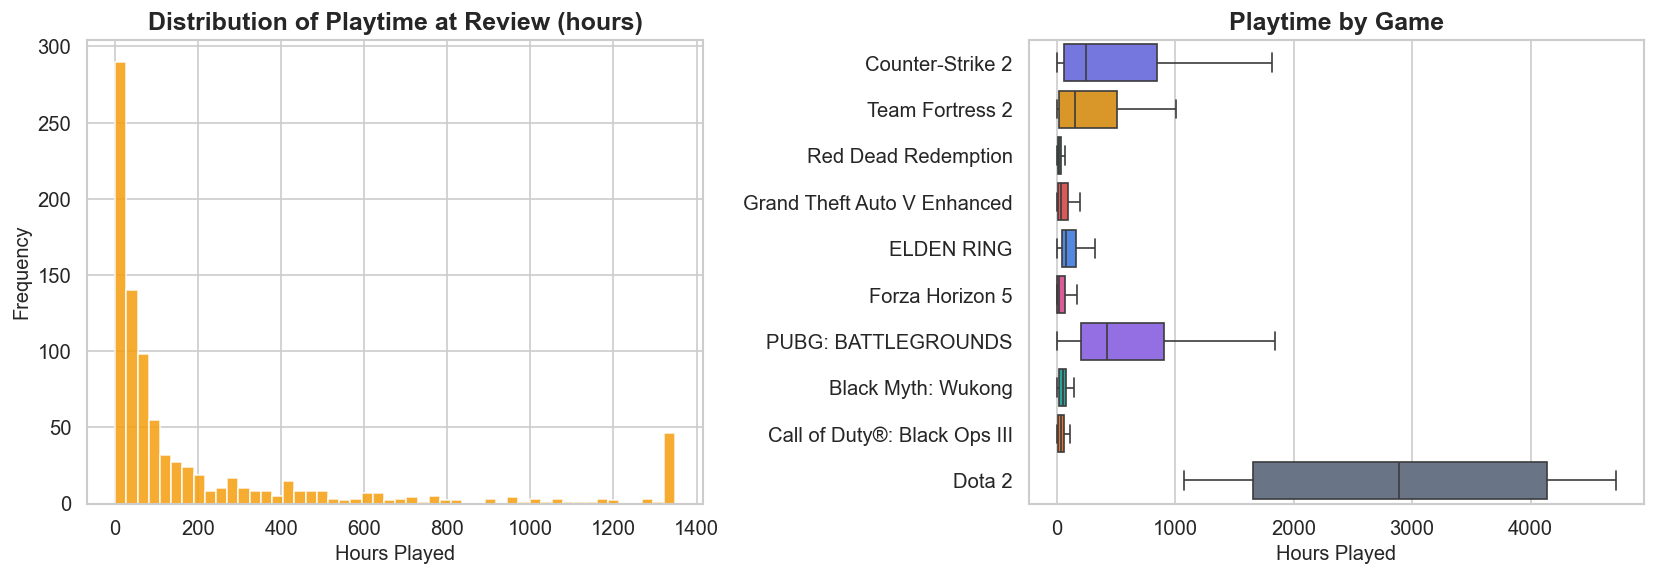

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pt_clipped = df["playtime_hours"].clip(upper=df["playtime_hours"].quantile(0.95))
pt_clipped.hist(bins=50, ax=axes[0], color=COLORS["secondary"], edgecolor="white", alpha=0.85)
axes[0].set_title("Distribution of Playtime at Review (hours)", fontweight="bold")
axes[0].set_xlabel("Hours Played")
axes[0].set_ylabel("Frequency")

sns.boxplot(data=df, x="playtime_hours", y="game_name",
            order=order, palette=COLORS["palette"], ax=axes[1], showfliers=False)
axes[1].set_title("Playtime by Game", fontweight="bold")
axes[1].set_xlabel("Hours Played")
axes[1].set_ylabel("")
plt.tight_layout()
plt.show()

### 4.5 — Helpful & Funny Votes Distribution

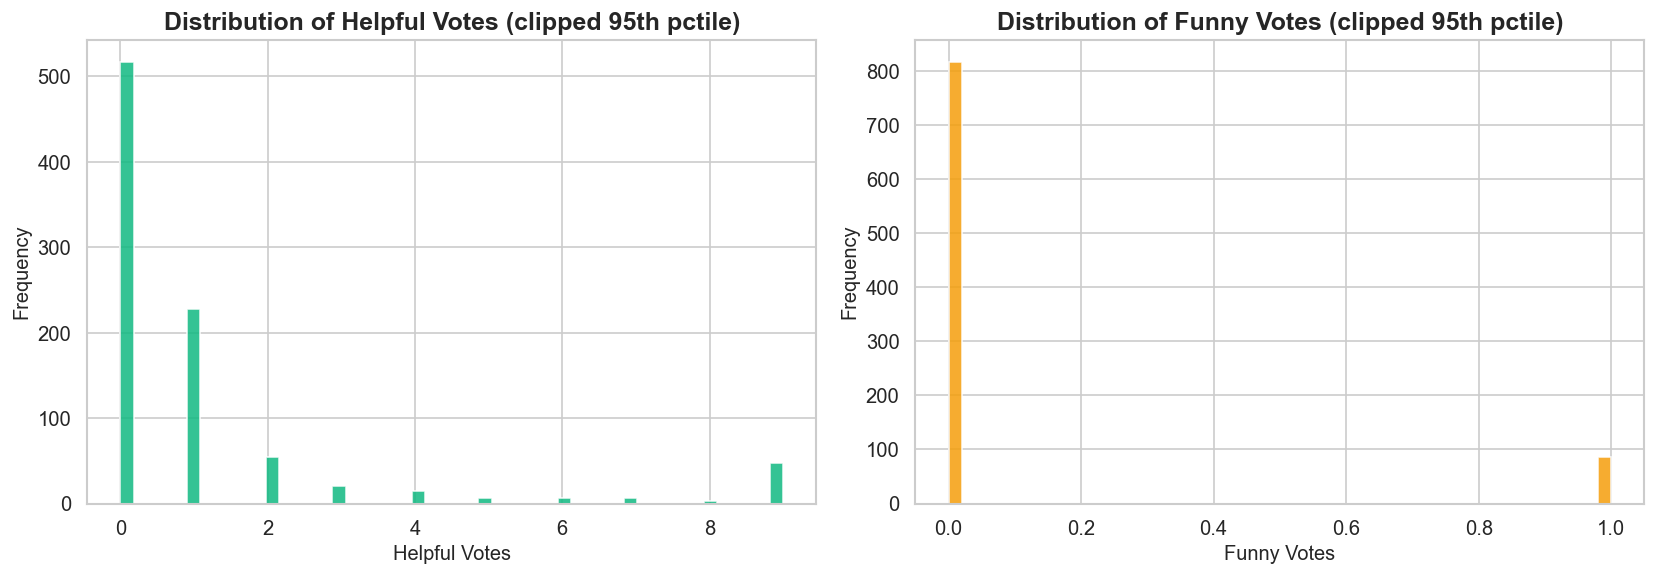

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df["votes_helpful"].clip(upper=df["votes_helpful"].quantile(0.95)).hist(
    bins=50, ax=axes[0], color=COLORS["positive"], edgecolor="white", alpha=0.85)
axes[0].set_title("Distribution of Helpful Votes (clipped 95th pctile)", fontweight="bold")
axes[0].set_xlabel("Helpful Votes")
axes[0].set_ylabel("Frequency")

df["votes_funny"].clip(upper=df["votes_funny"].quantile(0.95)).hist(
    bins=50, ax=axes[1], color=COLORS["secondary"], edgecolor="white", alpha=0.85)
axes[1].set_title("Distribution of Funny Votes (clipped 95th pctile)", fontweight="bold")
axes[1].set_xlabel("Funny Votes")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

## 5️⃣ Bivariate / Multivariate Analysis

### 5.1 — Playtime vs Review Length (by Recommendation)

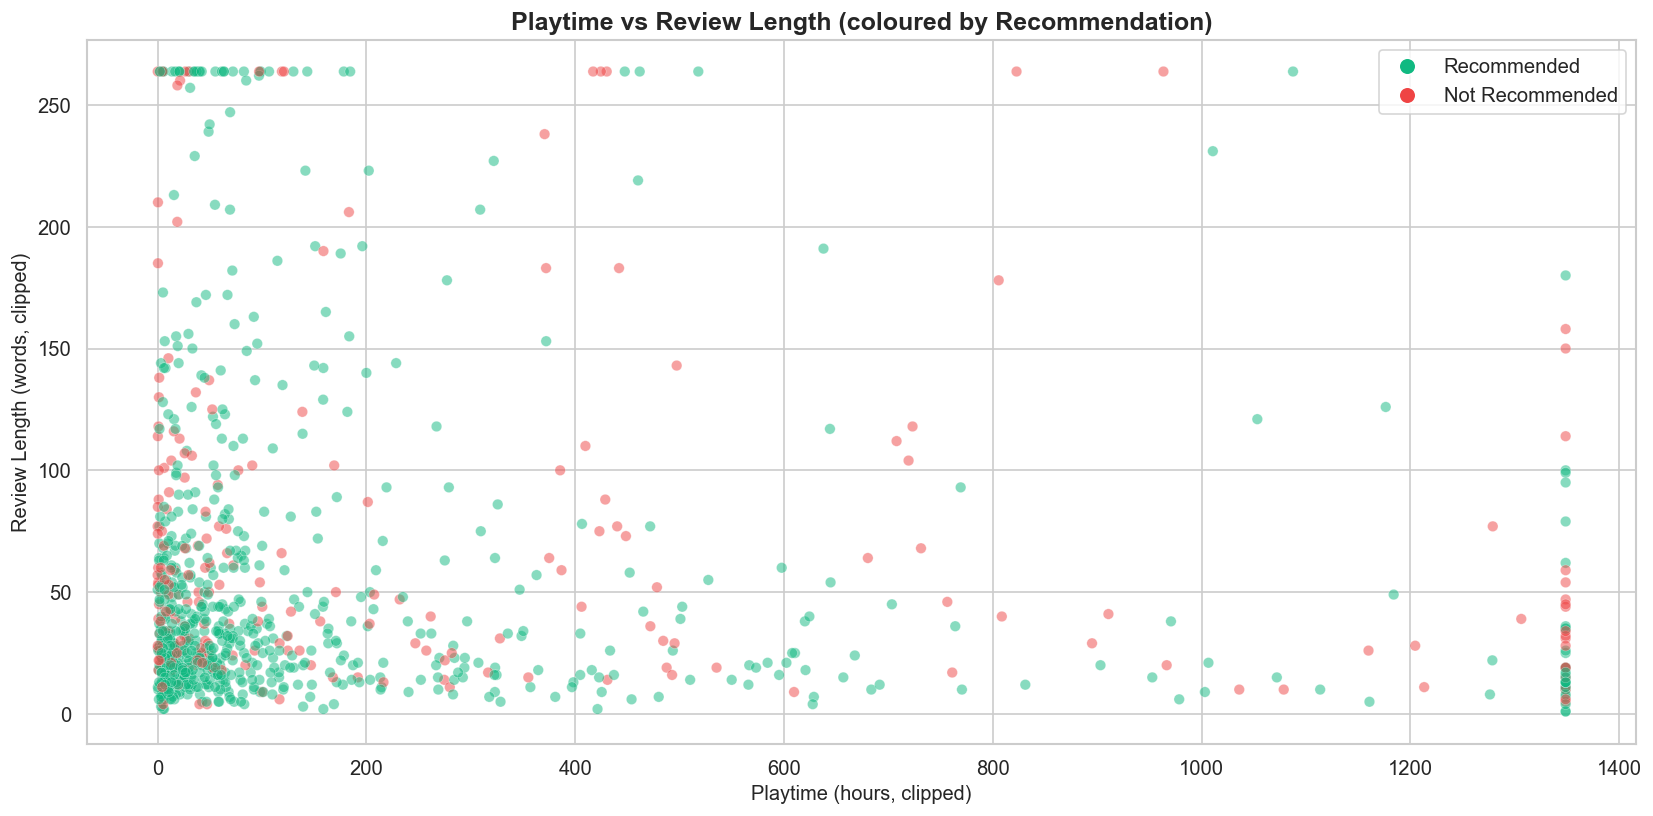

In [17]:
fig, ax = plt.subplots(figsize=(14, 7))
sample = df.sample(min(len(df), 2000), random_state=42)
ax.scatter(
    sample["playtime_hours"].clip(upper=sample["playtime_hours"].quantile(0.95)),
    sample["review_len_words"].clip(upper=sample["review_len_words"].quantile(0.95)),
    c=sample["recommended"].map({True: COLORS["positive"], False: COLORS["negative"]}),
    alpha=0.5, edgecolors="white", linewidth=0.3, s=40
)
ax.set_title("Playtime vs Review Length (coloured by Recommendation)", fontweight="bold")
ax.set_xlabel("Playtime (hours, clipped)")
ax.set_ylabel("Review Length (words, clipped)")
legend_elems = [
    Line2D([0],[0], marker="o", color="w", markerfacecolor=COLORS["positive"], markersize=10, label="Recommended"),
    Line2D([0],[0], marker="o", color="w", markerfacecolor=COLORS["negative"], markersize=10, label="Not Recommended")
]
ax.legend(handles=legend_elems, loc="upper right")
plt.tight_layout()
plt.show()

### 5.2 — Funny Votes vs Helpful Votes

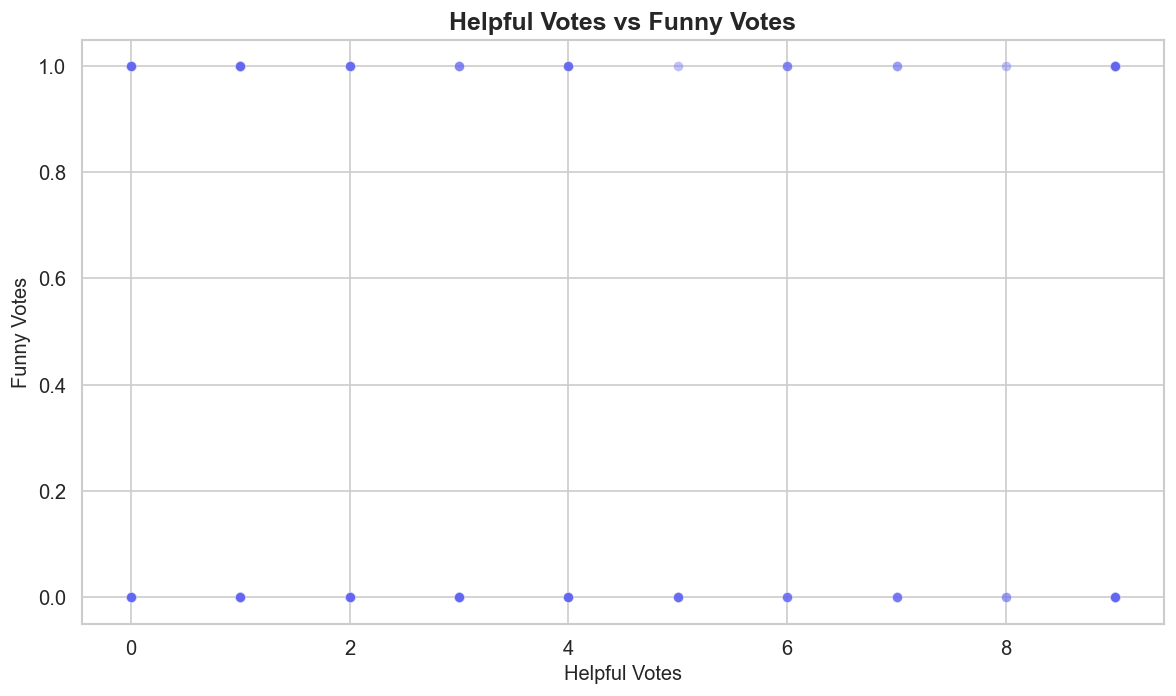

In [18]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(
    df["votes_helpful"].clip(upper=df["votes_helpful"].quantile(0.95)),
    df["votes_funny"].clip(upper=df["votes_funny"].quantile(0.95)),
    alpha=0.4, color=COLORS["primary"], edgecolors="white", linewidth=0.3, s=35
)
ax.set_title("Helpful Votes vs Funny Votes", fontweight="bold")
ax.set_xlabel("Helpful Votes")
ax.set_ylabel("Funny Votes")
plt.tight_layout()
plt.show()

### 5.3 — Mean Playtime vs Recommendation Rate per Game

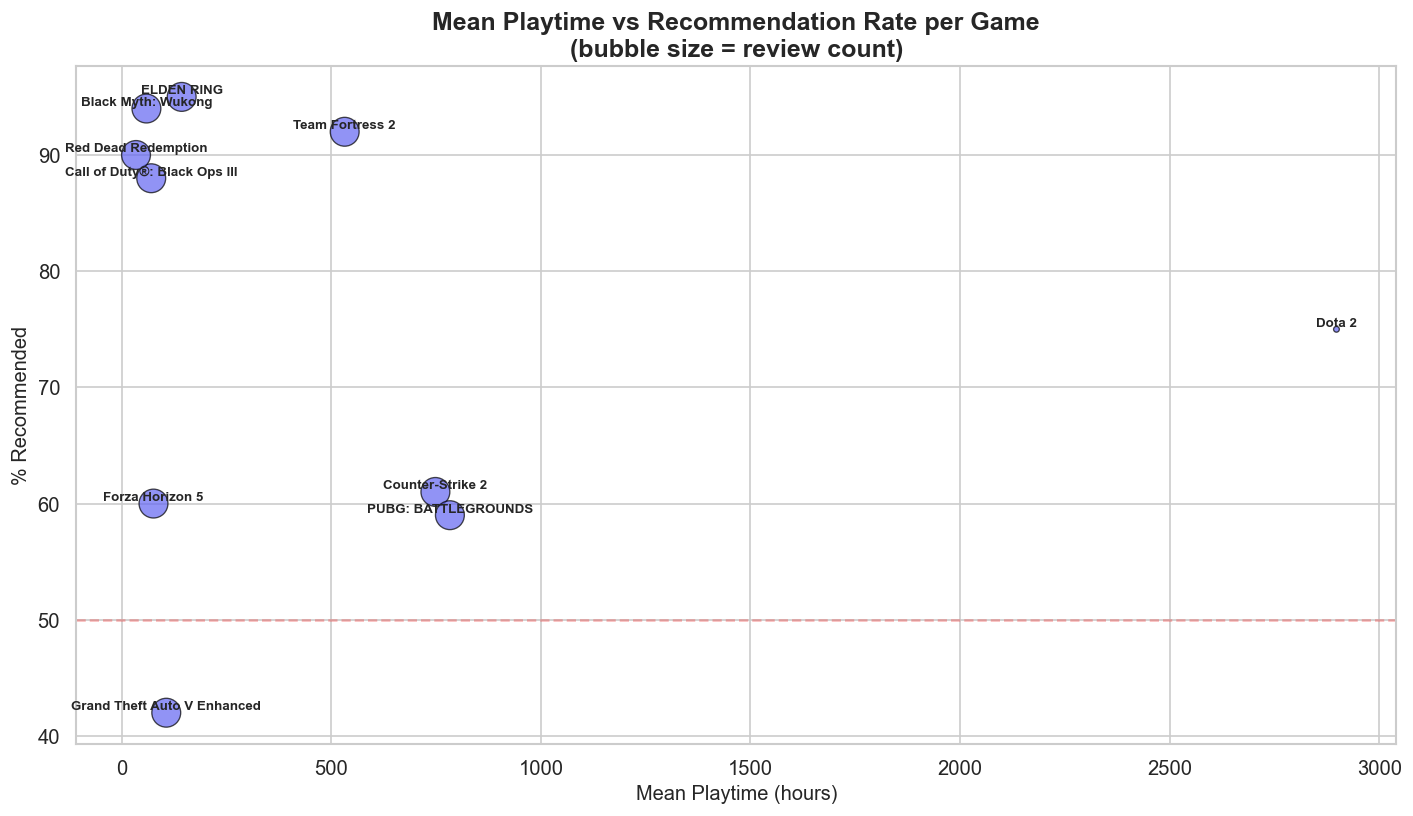

In [19]:
game_stats = df.groupby("game_name").agg(
    mean_playtime=("playtime_hours", "mean"),
    rec_rate=("recommended", "mean"),
    review_count=("review_text", "count")
).reset_index()

fig, ax = plt.subplots(figsize=(12, 7))
ax.scatter(
    game_stats["mean_playtime"],
    game_stats["rec_rate"] * 100,
    s=game_stats["review_count"] * 3,
    c=COLORS["primary"], alpha=0.7, edgecolors="black", linewidth=0.8
)
for _, row in game_stats.iterrows():
    ax.annotate(row["game_name"], (row["mean_playtime"], row["rec_rate"]*100),
                fontsize=8, ha="center", va="bottom", fontweight="bold")
ax.set_title("Mean Playtime vs Recommendation Rate per Game\n(bubble size = review count)",
             fontweight="bold")
ax.set_xlabel("Mean Playtime (hours)")
ax.set_ylabel("% Recommended")
ax.axhline(50, ls="--", color=COLORS["negative"], alpha=0.4)
plt.tight_layout()
plt.show()

### 5.4 — Review Length vs Recommendation (per Game)

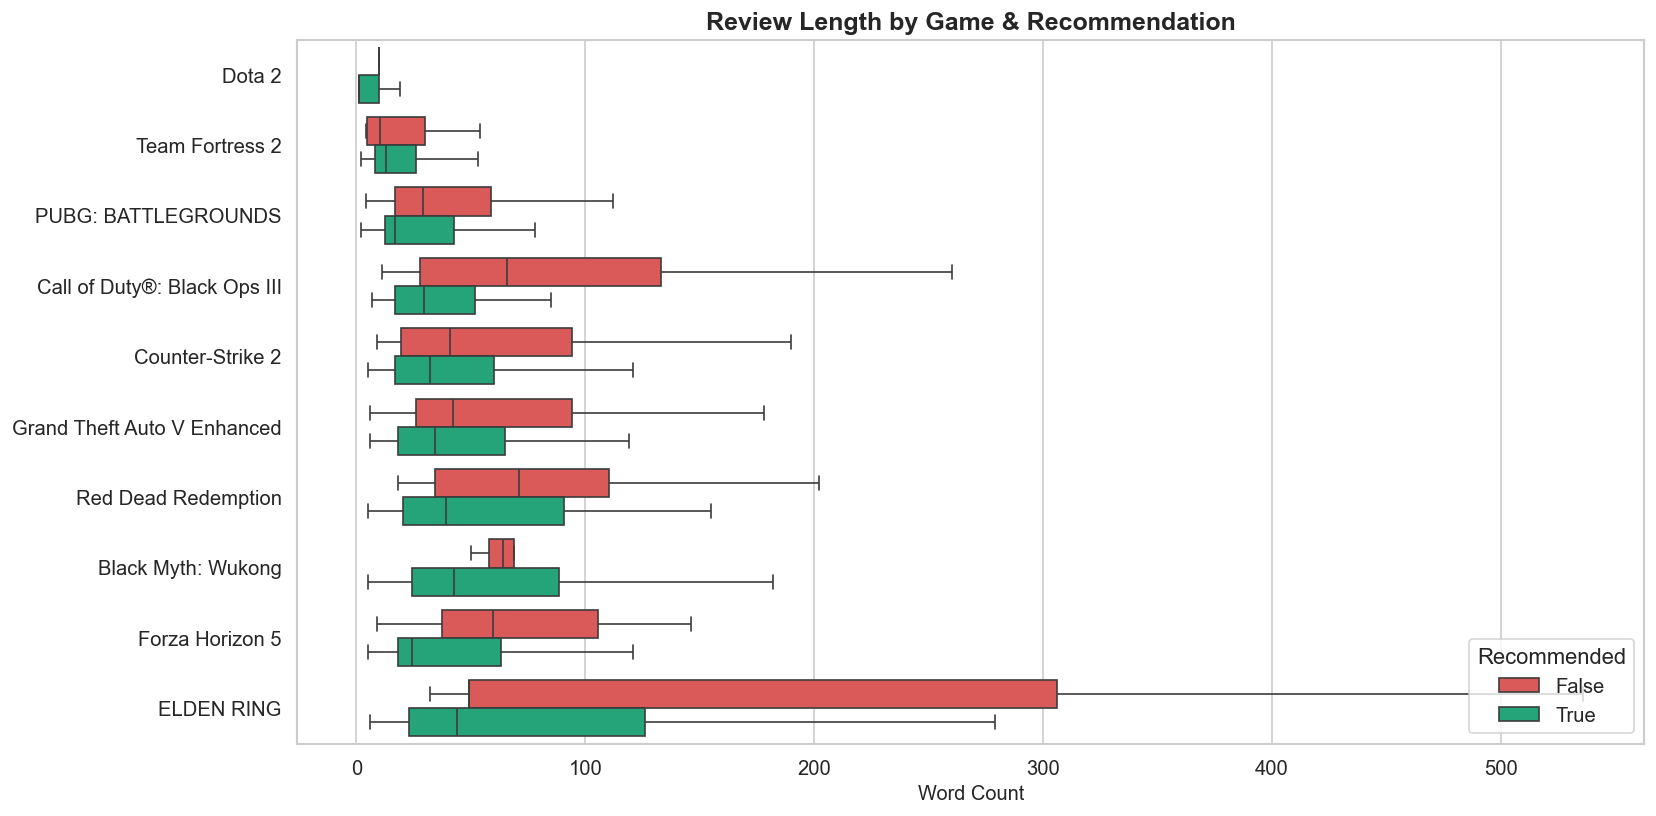

In [20]:
fig, ax = plt.subplots(figsize=(14, 7))
game_order = df.groupby("game_name")["review_len_words"].median().sort_values().index
sns.boxplot(data=df, x="review_len_words", y="game_name", hue="recommended",
            order=game_order, palette={True: COLORS["positive"], False: COLORS["negative"]},
            ax=ax, showfliers=False)
ax.set_title("Review Length by Game & Recommendation", fontweight="bold")
ax.set_xlabel("Word Count")
ax.set_ylabel("")
ax.legend(title="Recommended", loc="lower right")
plt.tight_layout()
plt.show()

## 6️⃣ Text Overview
A general look at the review text content — word frequencies, review length patterns,  
and most common terms. **No difficulty labelling here**, just raw text exploration.

### 6.1 — Most Common Words (all reviews)

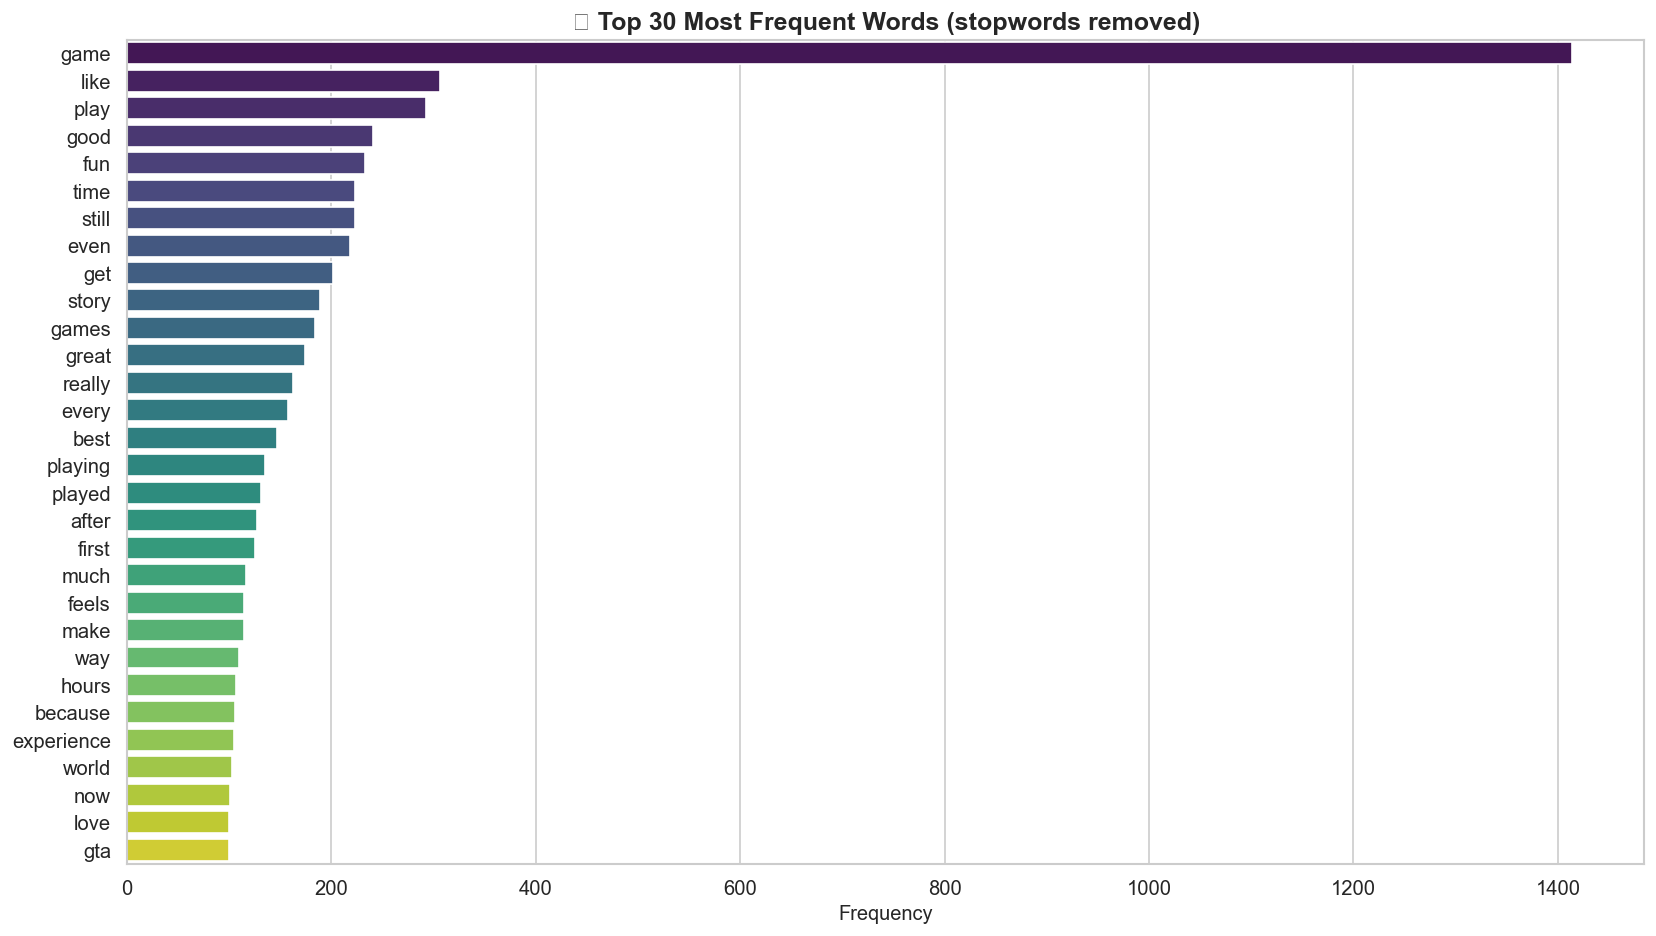

In [21]:
import re
from collections import Counter

# Basic tokenisation
all_words = []
stopwords = {"the","a","an","and","or","but","in","on","at","to","for","of","with",
             "is","it","this","that","was","are","be","has","have","had","not","you",
             "i","my","me","we","they","he","she","do","does","did","will","would",
             "can","could","should","just","so","if","as","by","from","about","been",
             "its","very","all","more","some","no","your","there","their","what","when",
             "who","how","than","then","also","into","only","other","which","them","up",
             "out","one","don","t","s","re","ve","ll","m","d"}

for text in df["review_text"].dropna().astype(str):
    tokens = re.findall(r"[a-z]+", text.lower())
    all_words.extend([w for w in tokens if w not in stopwords and len(w) > 2])

word_freq = Counter(all_words).most_common(30)
wf_df = pd.DataFrame(word_freq, columns=["word", "count"])

fig, ax = plt.subplots(figsize=(14, 8))
sns.barplot(data=wf_df, x="count", y="word", palette="viridis", ax=ax)
ax.set_title("🔤 Top 30 Most Frequent Words (stopwords removed)", fontweight="bold")
ax.set_xlabel("Frequency")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

### 6.2 — Most Common Words per Game (Top 3 Games by review count)

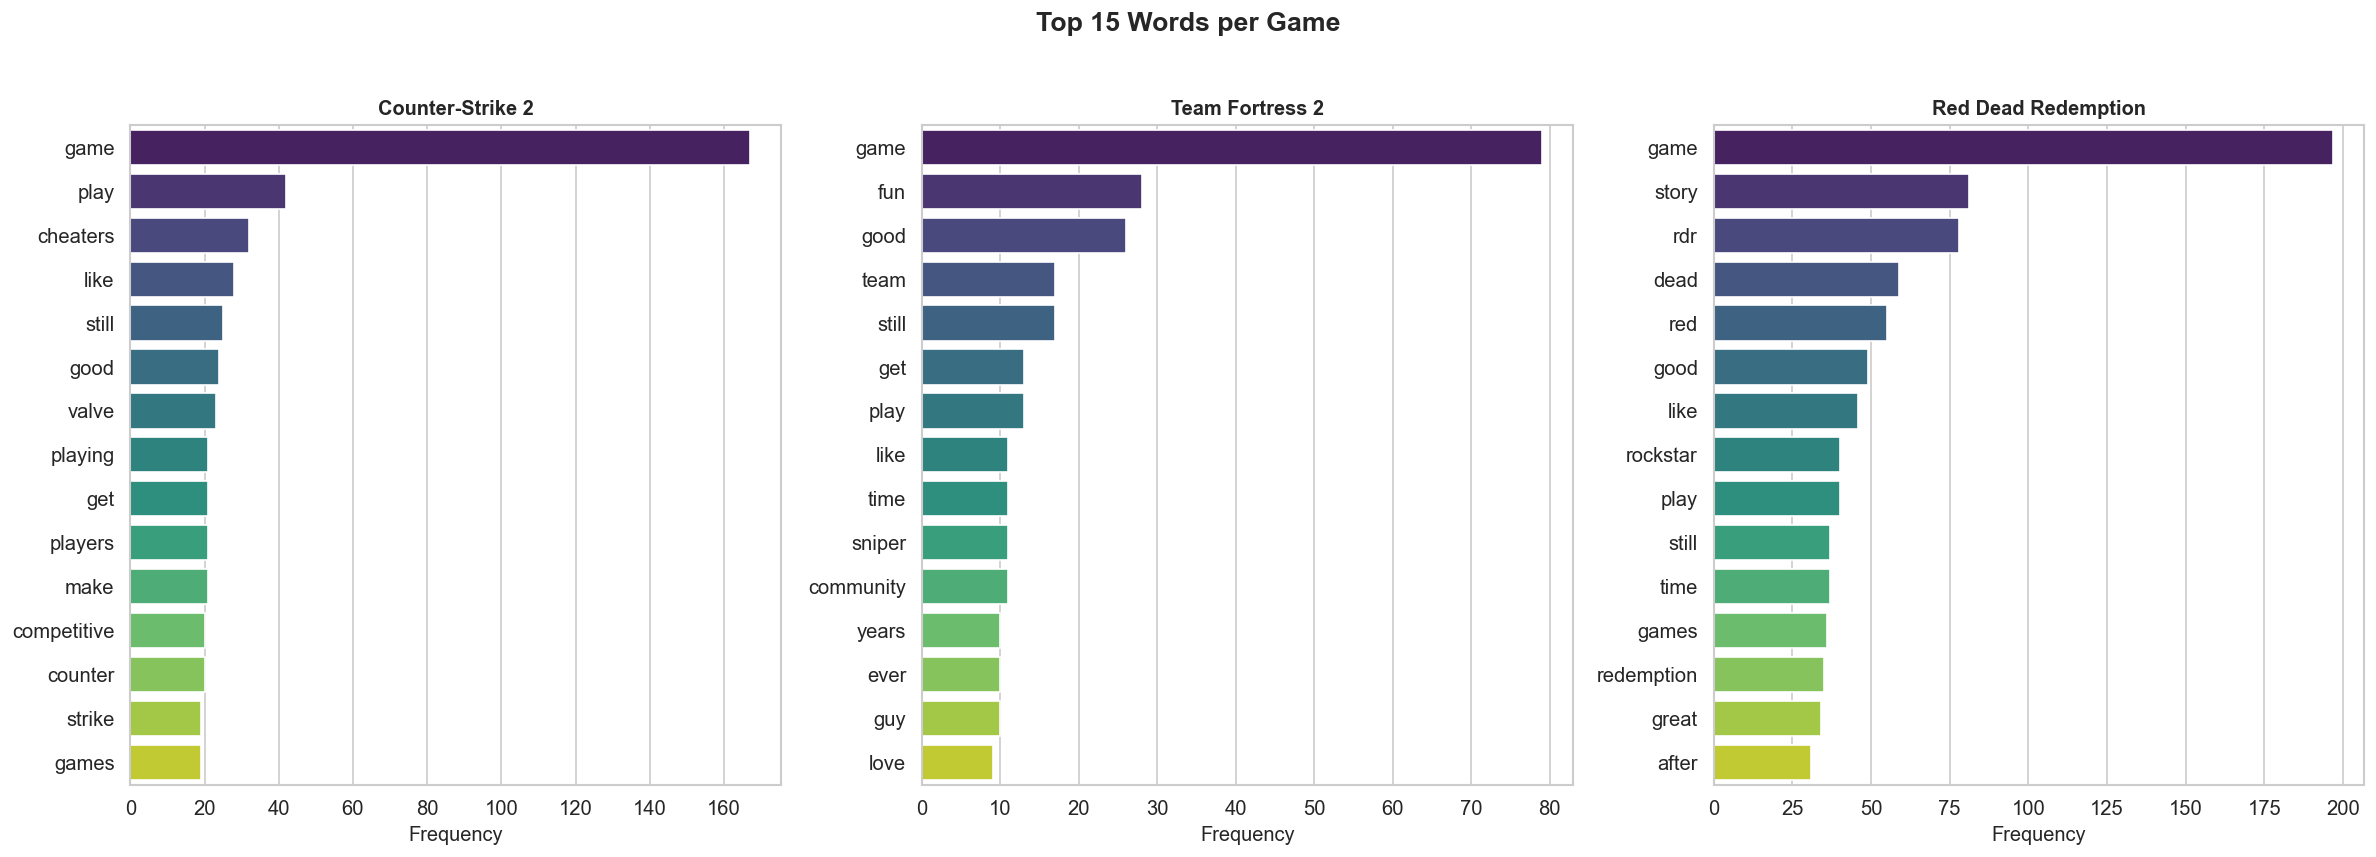

In [22]:
top3_games = df["game_name"].value_counts().head(3).index.tolist()

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
for idx, game in enumerate(top3_games):
    game_text = df[df["game_name"] == game]["review_text"].dropna().astype(str)
    words = []
    for text in game_text:
        tokens = re.findall(r"[a-z]+", text.lower())
        words.extend([w for w in tokens if w not in stopwords and len(w) > 2])
    top_w = pd.DataFrame(Counter(words).most_common(15), columns=["word", "count"])
    sns.barplot(data=top_w, x="count", y="word", palette="viridis", ax=axes[idx])
    axes[idx].set_title(f"{game}", fontweight="bold", fontsize=12)
    axes[idx].set_xlabel("Frequency")
    axes[idx].set_ylabel("")

plt.suptitle("Top 15 Words per Game", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### 6.3 — Review Length Statistics per Game

In [23]:
len_stats = df.groupby("game_name").agg(
    mean_chars=("review_len_chars", "mean"),
    median_chars=("review_len_chars", "median"),
    mean_words=("review_len_words", "mean"),
    median_words=("review_len_words", "median"),
    min_words=("review_len_words", "min"),
    max_words=("review_len_words", "max"),
    n_reviews=("review_text", "count")
).round(1).sort_values("mean_words", ascending=False)

print("📝 Review Length Statistics per Game\n")
print(len_stats.to_string())

📝 Review Length Statistics per Game

                              mean_chars  median_chars  mean_words  median_words  min_words  max_words  n_reviews
game_name                                                                                                        
Red Dead Redemption                609.2         212.0       108.1          42.5          5        918        100
ELDEN RING                         608.7         252.0       107.0          47.5          6       1186        100
Grand Theft Auto V Enhanced        565.4         214.5        99.0          39.0          6       1149        100
Forza Horizon 5                    412.8         244.0        76.5          46.0          5       1446        100
Black Myth: Wukong                 420.6         250.5        74.4          45.0          5        354        100
Counter-Strike 2                   351.2         185.0        62.6          34.5          5        725        100
Call of Duty®: Black Ops III       325.3         15

## 7️⃣ Correlation Analysis

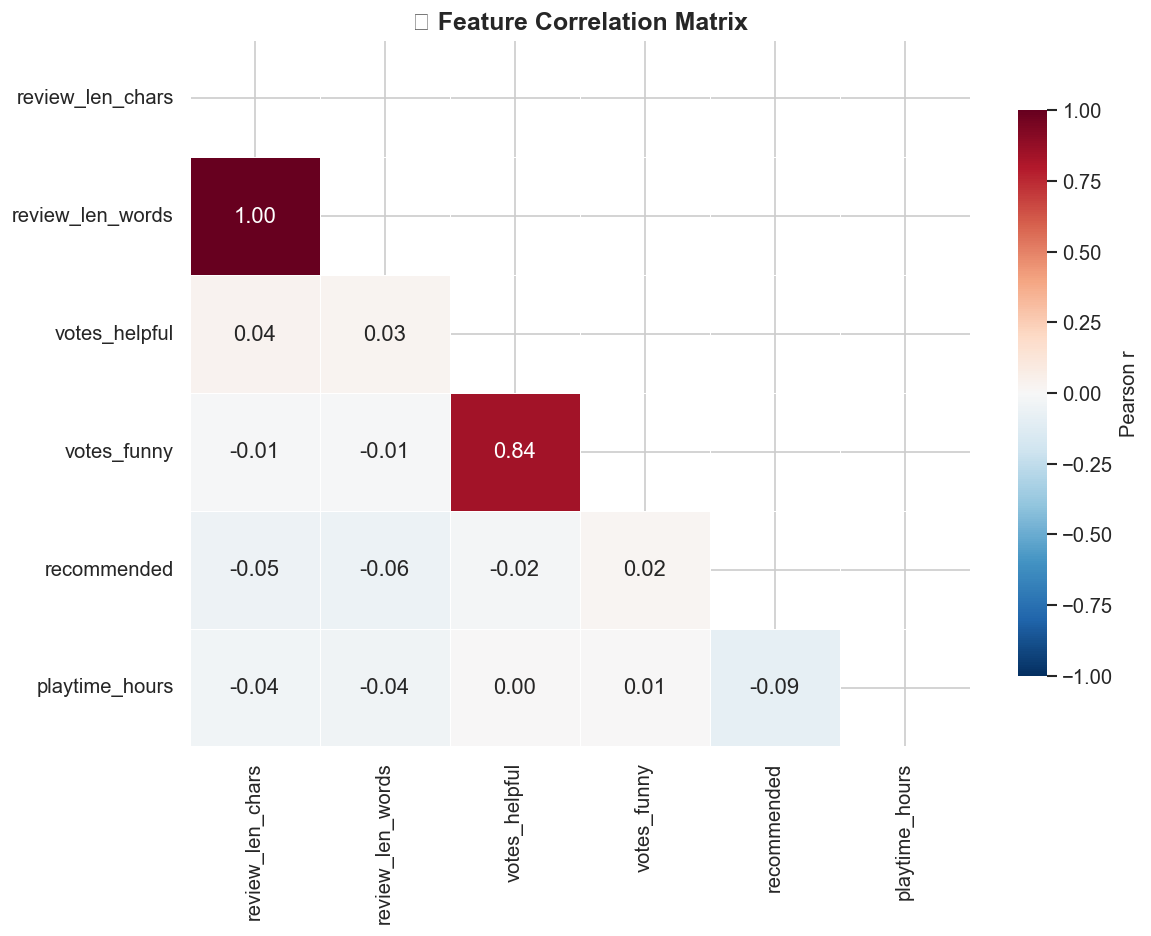

In [24]:
corr_cols = ["review_len_chars", "review_len_words", "votes_helpful",
             "votes_funny", "recommended", "playtime_hours"]

corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, vmin=-1, vmax=1, linewidths=0.5, ax=ax,
            cbar_kws={"shrink": 0.8, "label": "Pearson r"})
ax.set_title("🔗 Feature Correlation Matrix", fontweight="bold", fontsize=15)
plt.tight_layout()
plt.show()

## 8️⃣ Key Takeaways & Next Steps

### 📋 Observations
1. **Dataset composition** — review counts vary across games; some games dominate the dataset.
2. **Recommendation split** — most reviews tend to be positive, but the ratio differs per game.
3. **Playtime** — wide variance; some games have reviewers with thousands of hours, creating heavy right skew.
4. **Review length** — most reviews are short, with a long tail of detailed write-ups.
5. **Votes** — helpful and funny votes are heavily skewed toward zero (most reviews get little engagement).
6. **Text content** — word frequencies reflect each game's genre and themes.

### 🚀 Next Steps
- **Text preprocessing & feature engineering** — clean text, build TF-IDF, extract difficulty-related features.
- **Difficulty labelling** — define hard/easy keyword lexicons and build a composite difficulty score.
- **ML modelling** — train classifiers to predict difficulty from review features.